# 1. Imports

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
import pandas as pd
import numpy as np
import random

from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.crossover import SBXCrossover
from jmetal.algorithm.singleobjective import GeneticAlgorithm
from jmetal.operator.selection import BinaryTournamentSelection
from jmetal.core.solution import FloatSolution
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.core.problem import Problem

# 2. Lecture de la base de données

In [ ]:
df_diabetes = pd.read_csv("diabetes.csv")
df_yeast = pd.read_csv("yeast.csv")

# 3. Implémentation du Problème

In [ ]:
class PartialClassificationProblem(Problem):
    """
    Problème de classification partielle multi-objectif.
    Une solution = une règle avec bornes [bi, bs] pour chaque attribut.
    Objectif = maximiser F1 (donc minimiser -F1).
    """

    def __init__(self, X, y):
        # Appeler le constructeur parent en premier
        super().__init__()
        
        self.X = X
        self.y = y
        self.n_attributes = X.shape[1]

        # Définition des bornes globales des attributs
        mins = X.min(axis=0)
        maxs = X.max(axis=0)

        self.lower_bound = []
        self.upper_bound = []

        for i in range(self.n_attributes):
            self.lower_bound.extend([mins[i], mins[i]])
            self.upper_bound.extend([maxs[i], maxs[i]])

    def number_of_variables(self) -> int:
        return self.n_attributes

    def number_of_objectives(self) -> int:
        return 1

    def number_of_constraints(self) -> int:
        return 0

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        variables = solution.variables
        y_pred = []

        for instance in self.X:
            rule_active = True

            for i in range(self.n_attributes):
                bi = variables[2 * i]
                bs = variables[2 * i + 1]

                # Attribut actif si bi <= bs
                if bi <= bs:
                    if not (bi <= instance[i] <= bs):
                        rule_active = False
                        break

            y_pred.append(1 if rule_active else 0)

        # Gestion cas sans prédictions positives
        if sum(y_pred) == 0:
            precision = 0.0
            recall = 0.0
            f1 = 0.0
        else:
            precision = precision_score(self.y, y_pred, zero_division=0)
            recall = recall_score(self.y, y_pred, zero_division=0)
            f1 = f1_score(self.y, y_pred, average='binary', zero_division=0)

        solution.objectives[0] = -precision
        solution.objectives[1] = -recall
        solution.objectives[2] = -f1
        return solution

    def create_solution(self) -> FloatSolution:
        solution = FloatSolution(
            self.lower_bound,
            self.upper_bound,
            self.number_of_objectives(),
            self.number_of_constraints()
        )

        solution.variables = [
            random.uniform(self.lower_bound[i], self.upper_bound[i])
            for i in range(self.number_of_variables())
        ]

        return solution

    def name(self):
        return "PartialClassificationProblem"

# 4. Algorithmes Connus

## 4.1. Pima Diabetes

In [36]:
zero_impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_diabetes[zero_impossible_cols] = df_diabetes[zero_impossible_cols].replace(0, np.nan)
df_diabetes.fillna(df_diabetes.median(numeric_only=True), inplace=True)

X_diabetes = df_diabetes.drop('Outcome', axis=1)   # shape (768, 8)
y_diabetes= df_diabetes['Outcome']

X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes, y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes
)

# Important pour le SVM
scaler = StandardScaler()
X_train_diabetes_scaled = scaler.fit_transform(X_train_diabetes)
X_test_diabetes_scaled  = scaler.transform(X_test_diabetes)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

c45_model = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model_configs = {
    "Random Forest": (rf_model, X_train_diabetes, X_test_diabetes),
    "SVM": (svm_model, X_train_diabetes_scaled, X_test_diabetes_scaled),
    "C4.5": (c45_model, X_train_diabetes, X_test_diabetes),
}

results_diabetes = {}

for name, (model, X_tr, X_te) in model_configs.items():
    # Entrainer
    model.fit(X_tr, y_train_diabetes)

    # Prevoir
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]   # probability of class 1

    # Valider
    cv_scores = cross_val_score(model, X_tr, y_train_diabetes, cv=5, scoring='accuracy')

    results_diabetes[name] = {
        "Accuracy": accuracy_score(y_test_diabetes, y_pred),
        "ROC AUC":  roc_auc_score(y_test_diabetes, y_prob),
        "CV Mean":  cv_scores.mean(),
        "CV Std":   cv_scores.std(),
        "y_pred":   y_pred,
        "y_prob":   y_prob,
        "model":    model
    }


## 4.2. Yeast

In [ ]:
# Random Forest et SVM (boîtes noires) et C4.5 (boîte blanche).

zero_impossible_cols = ['Mit', 'Vac', 'Nuc']
df_yeast[zero_impossible_cols] = df_yeast[zero_impossible_cols].replace(0, np.nan)
df_yeast.fillna(df_yeast.median(numeric_only=True), inplace=True)

X_yeast = df_yeast.drop('Output', axis=1)   # shape (768, 8)
y_yeast= df_yeast['Output']

X_train_yeast, X_test_yeast, y_train_yeast, y_test_yeast = train_test_split(
    X_yeast, y_yeast,
    test_size=0.2,
    random_state=42,
    stratify=y_yeast
)

# Important pour le SVM
scaler = StandardScaler()
X_train_yeast_scaled = scaler.fit_transform(X_train_yeast)
X_test_yeast_scaled  = scaler.transform(X_test_yeast)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

c45_model = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model_configs = {
    "Random Forest": (rf_model, X_train_yeast, X_test_yeast),
    "SVM": (svm_model, X_train_yeast_scaled, X_test_yeast_scaled),
    "C4.5": (c45_model, X_train_yeast, X_test_yeast),
}

results_yeast = {}

for name, (model, X_tr, X_te) in model_configs.items():
    model.fit(X_tr, y_train_yeast)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    cv_scores = cross_val_score(model, X_tr, y_train_yeast, cv=5, scoring='accuracy')

    results_yeast[name] = {
        "Accuracy": accuracy_score(y_test_yeast, y_pred),
        "ROC AUC":  roc_auc_score(y_test_yeast, y_prob),
        "CV Mean":  cv_scores.mean(),
        "CV Std":   cv_scores.std(),
        "y_pred":   y_pred,
        "y_prob":   y_prob,
        "model":    model
    }

# 5. Algorithmes Génétiques

# 6. Comparaison des Algorithmes

## 6.1. Algorithmes Baseline

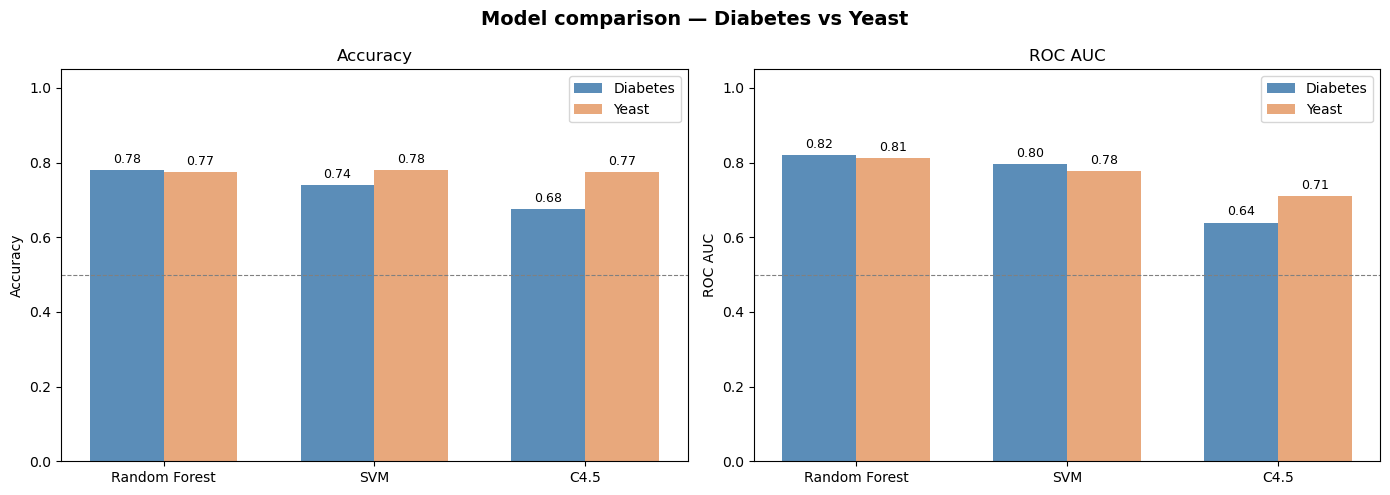

In [42]:
datasets = {
    "Diabetes": results_diabetes,
    "Yeast":    results_yeast
}

metrics   = ["Accuracy", "ROC AUC"]
model_names = ["Random Forest", "SVM", "C4.5"]
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model comparison — Diabetes vs Yeast", fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics):
    bars_diabetes = [results_diabetes[m][metric] for m in model_names]
    bars_yeast    = [results_yeast[m][metric]    for m in model_names]

    ax.bar(x - width/2, bars_diabetes, width, label="Diabetes", color="#5B8DB8")
    ax.bar(x + width/2, bars_yeast,    width, label="Yeast",    color="#E8A87C")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')

    # Add value labels on top of each bar
    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("comparison_metrics.png", dpi=150)
plt.show()

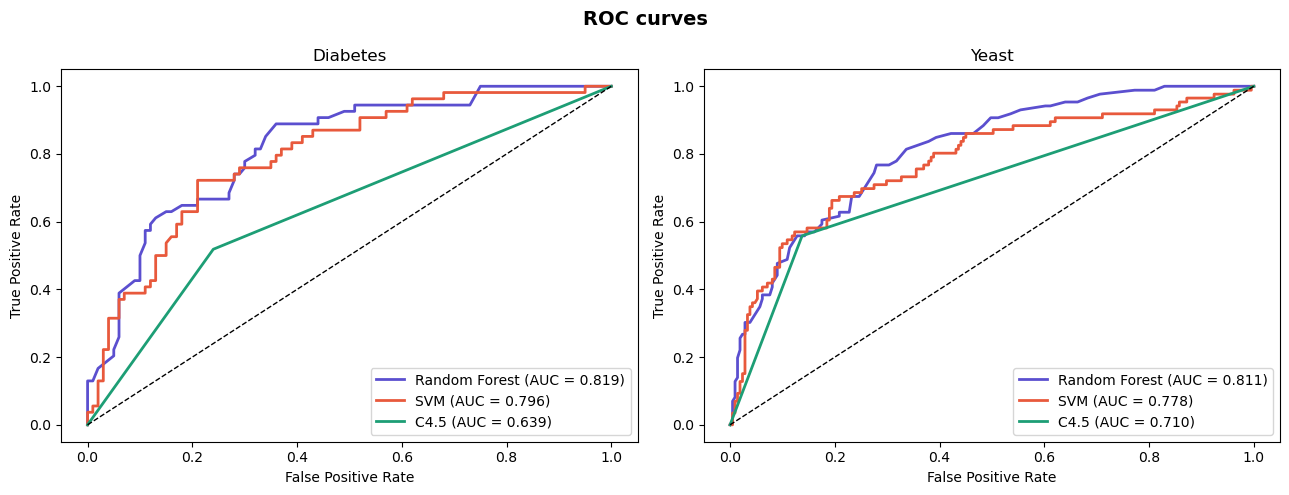

In [43]:
from sklearn.metrics import roc_curve

colors = {"Random Forest": "#5B4FCF", "SVM": "#E8593C", "C4.5": "#1D9E75"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ROC curves", fontsize=14, fontweight='bold')

for ax, (dataset_name, results) in zip(axes, datasets.items()):
    for model_name, res in results.items():
        fpr, tpr, _ = roc_curve(
            y_test_diabetes if dataset_name == "Diabetes" else y_test_yeast,
            res['y_prob']
        )
        ax.plot(fpr, tpr, lw=2, color=colors[model_name],
                label=f"{model_name} (AUC = {res['ROC AUC']:.3f})")

    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.set_title(dataset_name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig("roc_curves_comparison.png", dpi=150)
plt.show()

## 6.2. Algorithmes Génétiques

# 7. Analyse des Résultats